<a href="https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

I use Logistic Regression as the primary interpretable method and Random Forest as a controlled non-linear comparison.

Logistic Regression fits this lane because the target is binary and its predicted probabilities can rank content pages for human review. It provides a transparent learned benchmark and makes it possible to compare a machine-learning model with the Week-4 operational baseline.

Random Forest is included because relationships between CTR, impressions, average position, active days, and position volatility may not be fully linear. It can capture interactions without requiring additional manual scoring rules.

The primary metric is Precision@50 because the operational team has limited review capacity. The model is useful only when the 50 highest-ranked validation pages contain a higher observed positive rate than the Week-4 baseline.

The output is decision-support. It does not prove that a page requires a refresh or that any individual feature causes future search-performance decline.

In [1]:
# Install the required packages.
%pip install -q duckdb huggingface_hub scikit-learn pandas numpy matplotlib joblib

import os
import json
import subprocess
from pathlib import Path

import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import whoami

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
TOP_K = 50
TEST_SIZE = 0.20
CLASSIFICATION_THRESHOLD = 0.50

np.random.seed(SEED)

# ---------------------------------------------------------
# Repository setup
# ---------------------------------------------------------

REPO_URL = "https://github.com/Zafar488/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

current_directory = Path.cwd()

if current_directory.name == REPO_DIR:
    repo_root = current_directory

else:
    repo_root = Path("/content") / REPO_DIR

    if not repo_root.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(repo_root),
            ],
            check=True,
        )

    os.chdir(repo_root)

OUTPUT_DIR = Path("work/outputs/ml08")
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd())
print("Output directory:", OUTPUT_DIR)

# ---------------------------------------------------------
# Secure Hugging Face authentication
# ---------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. "
        "Add HF_TOKEN in the Colab Secrets panel "
        "and enable notebook access."
    )

hf_user = whoami(token=HF_TOKEN)

print(
    "Hugging Face authentication successful:",
    hf_user.get("name", "authenticated user"),
)

# ---------------------------------------------------------
# DuckDB warehouse connection
# ---------------------------------------------------------

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

WAREHOUSE_ROOT = "hf://datasets/FlyRank/internship-warehouse"

MARCH_FACT = (
    "read_parquet("
    f"'{WAREHOUSE_ROOT}/"
    "fact_content_daily_performance/"
    "month=2026-03/*.parquet'"
    ")"
)

print("DuckDB connection ready.")
print("Feature window: March 1–15, 2026")
print("Outcome window: March 16–31, 2026")

# ---------------------------------------------------------
# Verify source partition
# ---------------------------------------------------------

source_check = con.sql(
    f"""
    SELECT
        COUNT(*) AS total_rows,
        MIN(report_date) AS minimum_date,
        MAX(report_date) AS maximum_date,
        COUNT(DISTINCT client_hash_id) AS unique_clients,
        COUNT(
            DISTINCT (
                client_hash_id,
                content_hash_id
            )
        ) AS unique_client_pages
    FROM {MARCH_FACT}
    """
).df()

display(source_check)

minimum_date = pd.to_datetime(
    source_check.loc[0, "minimum_date"]
).date()

maximum_date = pd.to_datetime(
    source_check.loc[0, "maximum_date"]
).date()

assert str(minimum_date) == "2026-03-01"
assert str(maximum_date) == "2026-03-31"

print("March 2026 source verification passed.")

# ---------------------------------------------------------
# Build one row per anonymized client-page pair
# ---------------------------------------------------------

page_frame = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS feature_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS feature_clicks,

        AVG(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_position_volatility,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                 AND COALESCE(gsc_impressions, 0) > 0
                THEN report_date
            END
        ) AS feature_active_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS feature_available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS outcome_available_days

    FROM {MARCH_FACT}

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

print("Raw page rows:", f"{len(page_frame):,}")

# ---------------------------------------------------------
# Feature engineering and target
# ---------------------------------------------------------

page_frame["feature_ctr"] = np.where(
    page_frame["feature_impressions"] > 0,
    page_frame["feature_clicks"]
    / page_frame["feature_impressions"],
    np.nan,
)

volatility_median = (
    page_frame["feature_position_volatility"]
    .median()
)

page_frame["feature_position_volatility"] = (
    page_frame["feature_position_volatility"]
    .fillna(volatility_median)
)

page_frame["feature_daily_impressions"] = np.where(
    page_frame["feature_available_days"] > 0,
    page_frame["feature_impressions"]
    / page_frame["feature_available_days"],
    np.nan,
)

page_frame["outcome_daily_impressions"] = np.where(
    page_frame["outcome_available_days"] > 0,
    page_frame["outcome_impressions"]
    / page_frame["outcome_available_days"],
    np.nan,
)

page_frame["is_declining_proxy"] = (
    page_frame["outcome_daily_impressions"]
    <
    0.80
    * page_frame["feature_daily_impressions"]
).astype(int)

page_frame["log_feature_impressions"] = np.log1p(
    page_frame["feature_impressions"]
)

page_frame["position_band"] = pd.cut(
    page_frame["feature_avg_position"],
    bins=[0, 3, 10, 20],
    labels=[
        "Top 3",
        "Page 1",
        "Page 2",
    ],
    include_lowest=True,
)

# ---------------------------------------------------------
# Operational evaluation population
# ---------------------------------------------------------

model_frame = page_frame[
    (page_frame["feature_impressions"] >= 500)
    & (page_frame["feature_available_days"] >= 5)
    & (page_frame["outcome_available_days"] >= 5)
    & (page_frame["feature_avg_position"] > 0)
    & (page_frame["feature_avg_position"] <= 20)
    & (page_frame["feature_ctr"].notna())
    & (page_frame["position_band"].notna())
].copy()

model_frame = (
    model_frame
    .drop_duplicates(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Operational evaluation rows:",
    f"{len(model_frame):,}",
)

print(
    "Declining proxy rate:",
    round(
        model_frame["is_declining_proxy"].mean(),
        3,
    ),
)

print(
    "Number of clients:",
    model_frame["client_hash_id"].nunique(),
)

assert len(model_frame) > 0
assert model_frame["feature_impressions"].ge(500).all()
assert model_frame["feature_available_days"].ge(5).all()
assert model_frame["outcome_available_days"].ge(5).all()
assert model_frame["feature_avg_position"].gt(0).all()
assert model_frame["feature_avg_position"].le(20).all()

# ---------------------------------------------------------
# Feature roles
# ---------------------------------------------------------

numeric_features = [
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
]

categorical_features = [
    "position_band",
]

target_column = "is_declining_proxy"
group_column = "client_hash_id"

feature_columns = (
    numeric_features
    + categorical_features
)

method_receipt = pd.DataFrame(
    [
        {
            "method": "Logistic Regression",
            "role": "Primary interpretable model",
        },
        {
            "method": "Random Forest",
            "role": "Controlled non-linear comparison",
        },
        {
            "method": "ML-07 Baseline",
            "role": "Transparent operational benchmark",
        },
    ]
)

display(method_receipt)

assert target_column not in feature_columns
assert group_column not in feature_columns
assert "content_hash_id" not in feature_columns
assert "outcome_impressions" not in feature_columns
assert "outcome_daily_impressions" not in feature_columns

print("Method and feature-role checks passed.")

Working directory: /content/flyrank-ml-internship
Output directory: work/outputs/ml08
Hugging Face authentication successful: zafar4050
DuckDB connection ready.
Feature window: March 1–15, 2026
Outcome window: March 16–31, 2026


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,minimum_date,maximum_date,unique_clients,unique_client_pages
0,9841378,2026-03-01,2026-03-31,55,331437


March 2026 source verification passed.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw page rows: 331,437
Operational evaluation rows: 34,038
Declining proxy rate: 0.309
Number of clients: 32


,method,role
0,Logistic Regression,Primary interpretable model
1,Random Forest,Controlled non-linear comparison
2,ML-07 Baseline,Transparent operational benchmark


Method and feature-role checks passed.


## 2. Split design

I use a grouped client holdout with `GroupShuffleSplit`.

All pages belonging to one anonymized client are placed entirely in either the training set or the validation set. A client cannot appear in both sets.

This split is more honest than a random row split because pages from the same client may share measurement patterns, site structure, content practices, and search-performance behaviour. A random row split could allow the model to benefit from client-specific similarities that would not be available for a new client.

The feature window occurs before the outcome window. All predictive inputs use March 1–15, while the target uses March 16–31.

The Week-4 baseline, Logistic Regression, and Random Forest are evaluated on exactly the same grouped validation rows.

In [2]:
X = model_frame[feature_columns].copy()
y = model_frame[target_column].copy()
groups = model_frame[group_column].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

train_idx, validation_idx = next(
    splitter.split(
        X,
        y,
        groups=groups,
    )
)

train_frame = (
    model_frame
    .iloc[train_idx]
    .copy()
    .reset_index(drop=True)
)

validation_frame = (
    model_frame
    .iloc[validation_idx]
    .copy()
    .reset_index(drop=True)
)

X_train = train_frame[feature_columns].copy()
X_validation = validation_frame[feature_columns].copy()

y_train = train_frame[target_column].copy()
y_validation = validation_frame[target_column].copy()

train_clients = set(
    train_frame["client_hash_id"].unique()
)

validation_clients = set(
    validation_frame["client_hash_id"].unique()
)

client_overlap = train_clients.intersection(
    validation_clients
)

print("Training rows:", f"{len(train_frame):,}")
print("Validation rows:", f"{len(validation_frame):,}")

print("Training clients:", len(train_clients))
print("Validation clients:", len(validation_clients))

print(
    "Training declining rate:",
    round(y_train.mean(), 3),
)

print(
    "Validation declining rate:",
    round(y_validation.mean(), 3),
)

print("Client overlap:", len(client_overlap))

assert len(client_overlap) == 0
assert len(X_train) == len(y_train)
assert len(X_validation) == len(y_validation)

split_receipt = pd.DataFrame(
    [
        {
            "split": "training",
            "rows": len(train_frame),
            "clients": len(train_clients),
            "positive_rate": y_train.mean(),
        },
        {
            "split": "validation",
            "rows": len(validation_frame),
            "clients": len(validation_clients),
            "positive_rate": y_validation.mean(),
        },
    ]
)

display(split_receipt)

split_receipt.to_csv(
    OUTPUT_DIR / "split_receipt.csv",
    index=False,
)

# Training-only preprocessing pipeline

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)

print("Grouped validation check passed.")
print("Training-only preprocessing pipeline created.")

Training rows: 18,081
Validation rows: 15,957
Training clients: 25
Validation clients: 7
Training declining rate: 0.316
Validation declining rate: 0.301
Client overlap: 0


,split,rows,clients,positive_rate
0,training,18081,25,0.316354
1,validation,15957,7,0.300620


Grouped validation check passed.
Training-only preprocessing pipeline created.


## 3. Train + compare vs my baseline

The primary comparison metric is Precision@50.

Precision@50 measures the fraction of positive declining-proxy pages among the 50 highest-ranked validation pages. This matches the limited review capacity of the operational lane.

The Week-4 baseline is recreated using training-only references. It combines:

- 60% relative CTR weakness;
- 30% visibility percentile;
- 10% position-volatility percentile.

Expected CTR values for each position band and all percentile reference distributions are learned from the training clients only. They are then applied to the validation clients.

Logistic Regression and Random Forest are trained on the same training clients and evaluated on exactly the same validation rows as the baseline.

ROC-AUC and average precision are included as supporting ranking metrics. The main operational metric remains Precision@50.

In [3]:
# ---------------------------------------------------------
# Safe ranking metrics
# ---------------------------------------------------------

def prepare_evaluation_arrays(
    labels,
    scores,
):
    labels_array = np.asarray(
        labels,
        dtype=int,
    )

    scores_array = np.asarray(
        scores,
        dtype=float,
    )

    if labels_array.ndim != 1:
        raise ValueError(
            "Labels must be one-dimensional."
        )

    if scores_array.ndim != 1:
        raise ValueError(
            "Scores must be one-dimensional."
        )

    if len(labels_array) != len(scores_array):
        raise ValueError(
            "Labels and scores must have equal length."
        )

    if len(labels_array) == 0:
        raise ValueError(
            "Evaluation arrays cannot be empty."
        )

    if not np.isfinite(scores_array).all():
        raise ValueError(
            "Scores contain NaN or infinite values."
        )

    return labels_array, scores_array


def precision_at_k(
    labels,
    scores,
    k=50,
):
    labels_array, scores_array = (
        prepare_evaluation_arrays(
            labels,
            scores,
        )
    )

    effective_k = min(
        k,
        len(labels_array),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[
            ranked_indices
        ].mean()
    )


def recall_at_k(
    labels,
    scores,
    k=50,
):
    labels_array, scores_array = (
        prepare_evaluation_arrays(
            labels,
            scores,
        )
    )

    total_positives = labels_array.sum()

    if total_positives == 0:
        return np.nan

    effective_k = min(
        k,
        len(labels_array),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[
            ranked_indices
        ].sum()
        / total_positives
    )


def evaluate_ranking(
    method_name,
    labels,
    scores,
):
    labels_array, scores_array = (
        prepare_evaluation_arrays(
            labels,
            scores,
        )
    )

    return {
        "method": method_name,

        f"precision@{TOP_K}":
            precision_at_k(
                labels_array,
                scores_array,
                TOP_K,
            ),

        f"recall@{TOP_K}":
            recall_at_k(
                labels_array,
                scores_array,
                TOP_K,
            ),

        "average_precision":
            average_precision_score(
                labels_array,
                scores_array,
            ),

        "roc_auc":
            roc_auc_score(
                labels_array,
                scores_array,
            ),
    }


# ---------------------------------------------------------
# Training-referenced ML-07 baseline
# ---------------------------------------------------------

def percentile_from_training(
    training_values,
    new_values,
):
    training_array = np.asarray(
        training_values,
        dtype=float,
    )

    new_array = np.asarray(
        new_values,
        dtype=float,
    )

    training_array = training_array[
        np.isfinite(training_array)
    ]

    if len(training_array) == 0:
        raise ValueError(
            "Training reference distribution is empty."
        )

    training_array = np.sort(
        training_array
    )

    percentile_values = np.searchsorted(
        training_array,
        new_array,
        side="right",
    ) / len(training_array)

    return percentile_values


baseline_train = train_frame.copy()
baseline_validation = validation_frame.copy()

training_ctr_reference = (
    baseline_train
    .groupby(
        "position_band",
        observed=True,
    )["feature_ctr"]
    .median()
    .rename("expected_ctr_for_band")
)

expected_ctr_train = (
    baseline_train["position_band"]
    .map(training_ctr_reference)
    .astype(float)
)

expected_ctr_validation = (
    baseline_validation["position_band"]
    .map(training_ctr_reference)
    .astype(float)
)

global_training_ctr = float(
    baseline_train["feature_ctr"].median()
)

expected_ctr_train = (
    expected_ctr_train
    .fillna(global_training_ctr)
)

expected_ctr_validation = (
    expected_ctr_validation
    .fillna(global_training_ctr)
)

training_ctr_values = (
    baseline_train["feature_ctr"]
    .to_numpy(dtype=float)
)

validation_ctr_values = (
    baseline_validation["feature_ctr"]
    .to_numpy(dtype=float)
)

expected_ctr_train_array = (
    expected_ctr_train
    .to_numpy(dtype=float)
)

expected_ctr_validation_array = (
    expected_ctr_validation
    .to_numpy(dtype=float)
)

training_ctr_weakness = np.where(
    expected_ctr_train_array > 0,
    1.0
    - (
        training_ctr_values
        / expected_ctr_train_array
    ),
    0.0,
)

validation_ctr_weakness = np.where(
    expected_ctr_validation_array > 0,
    1.0
    - (
        validation_ctr_values
        / expected_ctr_validation_array
    ),
    0.0,
)

training_ctr_weakness = np.clip(
    np.nan_to_num(
        training_ctr_weakness,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    ),
    0.0,
    1.0,
)

validation_ctr_weakness = np.clip(
    np.nan_to_num(
        validation_ctr_weakness,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    ),
    0.0,
    1.0,
)

ctr_weakness_percentile = (
    percentile_from_training(
        training_ctr_weakness,
        validation_ctr_weakness,
    )
)

visibility_percentile = (
    percentile_from_training(
        baseline_train[
            "feature_impressions"
        ],
        baseline_validation[
            "feature_impressions"
        ],
    )
)

position_volatility_percentile = (
    percentile_from_training(
        baseline_train[
            "feature_position_volatility"
        ],
        baseline_validation[
            "feature_position_volatility"
        ],
    )
)

baseline_scores = (
    0.60
    * ctr_weakness_percentile

    + 0.30
    * visibility_percentile

    + 0.10
    * position_volatility_percentile
)

baseline_scores = np.nan_to_num(
    np.asarray(
        baseline_scores,
        dtype=float,
    ),
    nan=0.0,
    posinf=1.0,
    neginf=0.0,
)

assert len(baseline_scores) == len(
    y_validation
)

assert np.isfinite(
    baseline_scores
).all()

print("Training CTR references:")

display(
    training_ctr_reference
    .reset_index()
)

print(
    "Baseline validation scores:",
    len(baseline_scores),
)

# ---------------------------------------------------------
# Model definitions
# ---------------------------------------------------------

models = {
    "Logistic Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=10,
                    max_features="sqrt",
                    class_weight=(
                        "balanced_subsample"
                    ),
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

fitted_models = {}
validation_scores = {}

for model_name, model_pipeline in models.items():

    print("Training:", model_name)

    model_pipeline.fit(
        X_train,
        y_train,
    )

    model_scores = (
        model_pipeline
        .predict_proba(
            X_validation
        )[:, 1]
    )

    model_scores = np.asarray(
        model_scores,
        dtype=float,
    )

    if not np.isfinite(
        model_scores
    ).all():

        raise ValueError(
            f"{model_name} produced invalid scores."
        )

    fitted_models[
        model_name
    ] = model_pipeline

    validation_scores[
        model_name
    ] = model_scores

    print(
        f"{model_name} training completed."
    )

# ---------------------------------------------------------
# Same validation rows, same primary metric
# ---------------------------------------------------------

comparison_rows = [
    evaluate_ranking(
        "ML-07 Baseline",
        y_validation,
        baseline_scores,
    )
]

for model_name, model_scores in (
    validation_scores.items()
):

    comparison_rows.append(
        evaluate_ranking(
            model_name,
            y_validation,
            model_scores,
        )
    )

comparison_table = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        [
            f"precision@{TOP_K}",
            "average_precision",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison_table.round(4)
)

comparison_table.to_csv(
    OUTPUT_DIR
    / "model_vs_baseline.csv",
    index=False,
)

# Select the best learned model.
ml_comparison = comparison_table[
    comparison_table["method"]
    !=
    "ML-07 Baseline"
].copy()

best_model_name = (
    ml_comparison
    .iloc[0]["method"]
)

best_model = fitted_models[
    best_model_name
]

best_scores = validation_scores[
    best_model_name
]

baseline_precision_50 = float(
    comparison_table.loc[
        comparison_table["method"]
        ==
        "ML-07 Baseline",

        f"precision@{TOP_K}",
    ].iloc[0]
)

model_precision_50 = float(
    comparison_table.loc[
        comparison_table["method"]
        ==
        best_model_name,

        f"precision@{TOP_K}",
    ].iloc[0]
)

precision_difference = (
    model_precision_50
    -
    baseline_precision_50
)

print(
    "Selected ML model:",
    best_model_name,
)

print(
    "Baseline Precision@50:",
    round(
        baseline_precision_50,
        3,
    ),
)

print(
    "Model Precision@50:",
    round(
        model_precision_50,
        3,
    ),
)

print(
    "Measured difference:",
    round(
        precision_difference,
        3,
    ),
)

if precision_difference > 0:

    model_conclusion = (
        f"{best_model_name} measured a higher "
        f"Precision@50 than the ML-07 baseline "
        f"by {precision_difference:.3f}."
    )

elif np.isclose(
    precision_difference,
    0,
):

    model_conclusion = (
        f"{best_model_name} tied the ML-07 "
        "baseline on Precision@50. "
        "The simpler baseline remains competitive."
    )

else:

    model_conclusion = (
        f"{best_model_name} did not beat the "
        "ML-07 baseline on Precision@50. "
        "The transparent baseline remains stronger "
        "for this grouped validation split."
    )

print(model_conclusion)

Training CTR references:


,position_band,expected_ctr_for_band
0,Top 3,0.002745
1,Page 1,0.002103
2,Page 2,0.003120


Baseline validation scores: 15957
Training: Logistic Regression
Logistic Regression training completed.
Training: Random Forest
Random Forest training completed.


,method,precision@50,recall@50,average_precision,roc_auc
0,Logistic Regression,0.64,0.0067,0.3937,0.6175
1,Random Forest,0.56,0.0058,0.3887,0.6196
2,ML-07 Baseline,0.54,0.0056,0.3720,0.5755


Selected ML model: Logistic Regression
Baseline Precision@50: 0.54
Model Precision@50: 0.64
Measured difference: 0.1
Logistic Regression measured a higher Precision@50 than the ML-07 baseline by 0.100.


## 4. Errors and interpretation

I inspect errors from the selected machine-learning model rather than relying only on one aggregate metric.

A false positive is a page that the model classifies as declining although its observed future-window proxy is not declining. Such a page could consume limited reviewer capacity.

A false negative is a page with the declining proxy that receives a negative classification. Such a page may be missed by the review queue.

A probability threshold of 0.50 is used for threshold-based diagnostic analysis. This threshold is not used to select the operational model. The operational comparison remains based on Precision@50.

I also inspect the top-50 queue because it directly represents the primary metric.

Permutation importance is calculated on held-out validation rows. It shows which features the fitted model relied on for measured validation performance. It does not prove that those features cause future decline.

The results are observed and directional. They are intended for decision-support.

,Predicted not declining,Predicted declining
Actual not declining,5891,5269
Actual declining,1706,3091


              precision    recall  f1-score   support

           0      0.775     0.528     0.628     11160
           1      0.370     0.644     0.470      4797

    accuracy                          0.563     15957
   macro avg      0.573     0.586     0.549     15957
weighted avg      0.653     0.563     0.581     15957



,error_type,rows
0,correct,8982
1,false_positive,5269
2,false_negative,1706


False positive rows: 5,269


,client_hash_id,content_hash_id,model_score,feature_impressions,feature_ctr,feature_avg_position,feature_active_days,feature_position_volatility,position_band
0,client_23a62021009f63c4,content_dbbac2a9a0192b72,0.743835,943.0,0.0,8.382560,15,11.921020,Page 1
1,client_23a62021009f63c4,content_df544c08c540ba31,0.738293,740.0,0.0,8.894893,15,10.648152,Page 1
2,client_23a62021009f63c4,content_21669567da3dd14c,0.733027,676.0,0.0,8.709308,15,10.075964,Page 1
3,client_73cda7b4e4f265ea,content_1236bf49ebaa5283,0.726891,544.0,0.0,9.582610,15,8.533599,Page 1
4,client_23a62021009f63c4,content_bb06b0c780dc5341,0.726598,1008.0,0.0,9.547908,14,9.844973,Page 1
5,client_23a62021009f63c4,content_fbc8577b3cb61824,0.719700,529.0,0.0,8.150486,15,8.703132,Page 1
6,client_73cda7b4e4f265ea,content_6528b5e1d7e480a4,0.715838,532.0,0.0,7.846623,15,8.501523,Page 1
7,client_73cda7b4e4f265ea,content_e509cc91c6184757,0.712702,512.0,0.0,9.983669,15,6.640078,Page 1
8,client_fef1a8f436438636,content_612316e3451dda73,0.712116,672.0,0.0,9.787429,15,7.031592,Page 1
9,client_73cda7b4e4f265ea,content_b20b16c35f04f2cf,0.711447,574.0,0.0,9.454784,15,7.005537,Page 1


False negative rows: 1,706


,client_hash_id,content_hash_id,model_score,feature_impressions,feature_ctr,feature_avg_position,feature_active_days,feature_position_volatility,position_band
0,client_73cda7b4e4f265ea,content_9ef3f0974adfd621,0.499966,5011.0,0.002395,3.285120,15,0.537578,Page 1
1,client_73cda7b4e4f265ea,content_3408eba73ad695a9,0.499774,868.0,0.003456,1.741515,15,1.082347,Top 3
2,client_73cda7b4e4f265ea,content_75c557a190800081,0.499647,534.0,0.003745,1.819752,15,1.214575,Top 3
3,client_23a62021009f63c4,content_ac66f4fff07580e7,0.499634,1128.0,0.000000,14.503023,15,5.762159,Page 2
4,client_73cda7b4e4f265ea,content_cafc4da4511a3856,0.499577,1012.0,0.002964,1.120658,15,0.354755,Top 3
5,client_73cda7b4e4f265ea,content_c059ab287c00213f,0.499563,23705.0,0.001941,4.746578,15,0.411179,Page 1
6,client_73cda7b4e4f265ea,content_39493f9151919a53,0.499510,1523.0,0.003283,4.268746,15,0.738778,Page 1
7,client_fef1a8f436438636,content_59971c3b8ec75942,0.499383,884.0,0.000000,12.707480,15,6.697304,Page 2
8,client_23a62021009f63c4,content_6279cc0d882f39e8,0.499355,1043.0,0.000000,15.131004,15,5.211151,Page 2
9,client_73cda7b4e4f265ea,content_a6eb73bf518e87cd,0.499322,6256.0,0.002558,4.528565,15,0.354816,Page 1


Top-50 true positives: 32
Top-50 false positives: 18
Top-50 observed positive rate: 0.64


,rank,client_hash_id,content_hash_id,model_score,is_declining_proxy,feature_impressions,feature_ctr,feature_avg_position,feature_position_volatility,position_band
0,1,client_73cda7b4e4f265ea,content_e98ee386179e4124,0.805261,1,653.0,0.0,9.157493,21.105039,Page 1
1,2,client_fef1a8f436438636,content_68f69aa4e67a2926,0.751316,1,504.0,0.0,9.372902,11.372153,Page 1
2,3,client_23a62021009f63c4,content_dbbac2a9a0192b72,0.743835,0,943.0,0.0,8.382560,11.921020,Page 1
3,4,client_23a62021009f63c4,content_df544c08c540ba31,0.738293,0,740.0,0.0,8.894893,10.648152,Page 1
4,5,client_23a62021009f63c4,content_21669567da3dd14c,0.733027,0,676.0,0.0,8.709308,10.075964,Page 1
5,6,client_73cda7b4e4f265ea,content_39eca839ac1c8ffb,0.729817,1,589.0,0.0,8.939220,9.396693,Page 1
6,7,client_fef1a8f436438636,content_d7e6dca138b2d9bc,0.728303,1,579.0,0.0,9.900844,8.542776,Page 1
7,8,client_73cda7b4e4f265ea,content_1236bf49ebaa5283,0.726891,0,544.0,0.0,9.582610,8.533599,Page 1
8,9,client_23a62021009f63c4,content_bb06b0c780dc5341,0.726598,0,1008.0,0.0,9.547908,9.844973,Page 1
9,10,client_fef1a8f436438636,content_de5791c7b8593577,0.725637,1,530.0,0.0,9.708983,8.277110,Page 1


,feature,importance_mean,importance_std,stable_positive
0,feature_ctr,0.09743,0.00390,True
1,position_band,0.02943,0.00288,True
2,feature_avg_position,0.02029,0.00140,True
3,feature_position_volatility,0.01343,0.00095,True
4,log_feature_impressions,0.00341,0.00052,True
5,feature_clicks,0.00041,0.00013,True
6,feature_active_days,-0.00100,0.00052,False


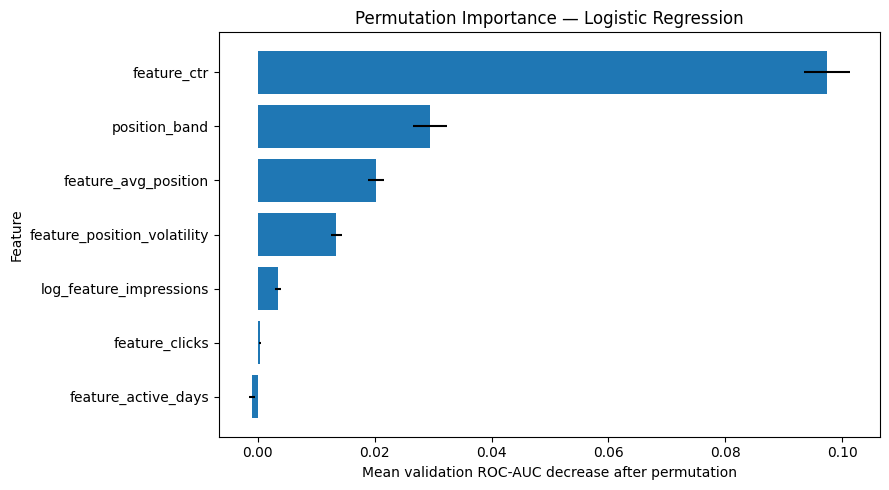


At the 0.50 probability threshold,
the selected Logistic Regression model produced
5,269 false positives and
1,706 false negatives.

The top-50 review queue contained
32 pages with the declining proxy and
18 pages without the declining proxy.

The measured Precision@50 was
0.640.

Held-out permutation importance showed that the model
relied most on feature_ctr,
position_band, and
feature_avg_position.

These findings are observed and directional.
They support human review prioritization but do not
establish that any feature causes future decline.

Saved model: work/outputs/ml08/models/ml08_selected_model.joblib
Saved outputs: work/outputs/ml08


,check,passed
0,Every section has supporting code,True
1,Modeling frame is non-empty,True
2,Training set is non-empty,True
3,Validation set is non-empty,True
4,No client overlap,True
5,Identifiers are not model features,True
6,Outcome columns are not model features,True
7,Baseline uses same validation rows,True
8,Selected model uses same validation rows,True
9,Baseline scores are finite,True


All ML-08 self-checks passed.


In [4]:
# ---------------------------------------------------------
# Threshold-based predictions
# ---------------------------------------------------------

best_predictions = (
    np.asarray(
        best_scores,
        dtype=float,
    )
    >=
    CLASSIFICATION_THRESHOLD
).astype(int)

confusion = confusion_matrix(
    y_validation,
    best_predictions,
    labels=[0, 1],
)

tn, fp, fn, tp = confusion.ravel()

confusion_table = pd.DataFrame(
    confusion,
    index=[
        "Actual not declining",
        "Actual declining",
    ],
    columns=[
        "Predicted not declining",
        "Predicted declining",
    ],
)

display(confusion_table)

print(
    classification_report(
        y_validation,
        best_predictions,
        digits=3,
        zero_division=0,
    )
)

# ---------------------------------------------------------
# Row-level validation results
# ---------------------------------------------------------

error_frame = validation_frame[
    [
        "client_hash_id",
        "content_hash_id",
        "feature_impressions",
        "feature_clicks",
        "feature_ctr",
        "feature_avg_position",
        "feature_active_days",
        "feature_position_volatility",
        "position_band",
        "is_declining_proxy",
    ]
].copy()

error_frame["model_score"] = best_scores

error_frame["predicted_at_0_5"] = (
    best_predictions
)

error_frame["error_type"] = np.select(
    [
        (
            error_frame[
                "is_declining_proxy"
            ].eq(0)

            &

            error_frame[
                "predicted_at_0_5"
            ].eq(1)
        ),

        (
            error_frame[
                "is_declining_proxy"
            ].eq(1)

            &

            error_frame[
                "predicted_at_0_5"
            ].eq(0)
        ),
    ],

    [
        "false_positive",
        "false_negative",
    ],

    default="correct",
)

error_counts = (
    error_frame["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="rows")
)

display(error_counts)

# ---------------------------------------------------------
# False positives
# ---------------------------------------------------------

false_positives = (
    error_frame[
        error_frame["error_type"]
        ==
        "false_positive"
    ]
    .sort_values(
        "model_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "False positive rows:",
    f"{len(false_positives):,}",
)

display(
    false_positives[
        [
            "client_hash_id",
            "content_hash_id",
            "model_score",
            "feature_impressions",
            "feature_ctr",
            "feature_avg_position",
            "feature_active_days",
            "feature_position_volatility",
            "position_band",
        ]
    ].head(10)
)

# ---------------------------------------------------------
# False negatives
# ---------------------------------------------------------

false_negatives = (
    error_frame[
        error_frame["error_type"]
        ==
        "false_negative"
    ]
    .sort_values(
        "model_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "False negative rows:",
    f"{len(false_negatives):,}",
)

display(
    false_negatives[
        [
            "client_hash_id",
            "content_hash_id",
            "model_score",
            "feature_impressions",
            "feature_ctr",
            "feature_avg_position",
            "feature_active_days",
            "feature_position_volatility",
            "position_band",
        ]
    ].head(10)
)

# ---------------------------------------------------------
# Top-50 operational queue
# ---------------------------------------------------------

top_50_review = (
    error_frame
    .sort_values(
        "model_score",
        ascending=False,
        kind="mergesort",
    )
    .head(TOP_K)
    .copy()
    .reset_index(drop=True)
)

top_50_review.insert(
    0,
    "rank",
    np.arange(
        1,
        len(top_50_review) + 1,
    ),
)

top_50_true_positives = int(
    top_50_review[
        "is_declining_proxy"
    ].sum()
)

top_50_false_positives = int(
    len(top_50_review)
    -
    top_50_true_positives
)

top_50_precision = float(
    top_50_review[
        "is_declining_proxy"
    ].mean()
)

print(
    "Top-50 true positives:",
    top_50_true_positives,
)

print(
    "Top-50 false positives:",
    top_50_false_positives,
)

print(
    "Top-50 observed positive rate:",
    round(
        top_50_precision,
        3,
    ),
)

display(
    top_50_review[
        [
            "rank",
            "client_hash_id",
            "content_hash_id",
            "model_score",
            "is_declining_proxy",
            "feature_impressions",
            "feature_ctr",
            "feature_avg_position",
            "feature_position_volatility",
            "position_band",
        ]
    ].head(20)
)

# ---------------------------------------------------------
# Held-out permutation importance
# ---------------------------------------------------------

permutation_result = permutation_importance(
    best_model,
    X_validation,
    y_validation,
    scoring="roc_auc",
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "feature":
            feature_columns,

        "importance_mean":
            permutation_result.importances_mean,

        "importance_std":
            permutation_result.importances_std,
    }
)

importance_table[
    "stable_positive"
] = (
    importance_table[
        "importance_mean"
    ]
    -
    2
    *
    importance_table[
        "importance_std"
    ]
    >
    0
)

importance_table = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    importance_table.round(5)
)

importance_table.to_csv(
    OUTPUT_DIR
    / "permutation_importance.csv",
    index=False,
)

plot_importance = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_importance["feature"],
    plot_importance[
        "importance_mean"
    ],
    xerr=plot_importance[
        "importance_std"
    ],
)

plt.xlabel(
    "Mean validation ROC-AUC decrease after permutation"
)

plt.ylabel("Feature")

plt.title(
    f"Permutation Importance — {best_model_name}"
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Honest measured interpretation
# ---------------------------------------------------------

false_positive_count = int(
    (
        error_frame["error_type"]
        ==
        "false_positive"
    ).sum()
)

false_negative_count = int(
    (
        error_frame["error_type"]
        ==
        "false_negative"
    ).sum()
)

top_three_features = (
    importance_table
    .head(3)["feature"]
    .tolist()
)

print(
    f"""
At the {CLASSIFICATION_THRESHOLD:.2f} probability threshold,
the selected {best_model_name} model produced
{false_positive_count:,} false positives and
{false_negative_count:,} false negatives.

The top-{TOP_K} review queue contained
{top_50_true_positives} pages with the declining proxy and
{top_50_false_positives} pages without the declining proxy.

The measured Precision@{TOP_K} was
{top_50_precision:.3f}.

Held-out permutation importance showed that the model
relied most on {top_three_features[0]},
{top_three_features[1]}, and
{top_three_features[2]}.

These findings are observed and directional.
They support human review prioritization but do not
establish that any feature causes future decline.
"""
)

# ---------------------------------------------------------
# Save complete model pipeline and outputs
# ---------------------------------------------------------

model_path = (
    MODEL_DIR
    / "ml08_selected_model.joblib"
)

joblib.dump(
    best_model,
    model_path,
)

final_validation_output = (
    error_frame.copy()
)

final_validation_output[
    "baseline_action_score"
] = baseline_scores

final_validation_output[
    "model_decline_probability"
] = best_scores

final_validation_output[
    "model_rank"
] = (
    final_validation_output[
        "model_decline_probability"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

final_validation_output = (
    final_validation_output
    .sort_values(
        "model_rank"
    )
    .reset_index(drop=True)
)

final_validation_output.to_csv(
    OUTPUT_DIR
    / "validation_model_scores.csv",
    index=False,
)

top_50_review.to_csv(
    OUTPUT_DIR
    / "top_50_review_queue.csv",
    index=False,
)

false_positives.to_csv(
    OUTPUT_DIR
    / "false_positives.csv",
    index=False,
)

false_negatives.to_csv(
    OUTPUT_DIR
    / "false_negatives.csv",
    index=False,
)

confusion_table.to_csv(
    OUTPUT_DIR
    / "confusion_matrix.csv",
)

classification_report_df = pd.DataFrame(
    classification_report(
        y_validation,
        best_predictions,
        output_dict=True,
        zero_division=0,
    )
).transpose()

classification_report_df.to_csv(
    OUTPUT_DIR
    / "classification_report.csv",
)

metrics_receipt = {
    "assignment": "ML-08",

    "lane":
        "Refresh / Content Opportunity Scoring",

    "feature_window":
        "2026-03-01 to 2026-03-15",

    "outcome_window":
        "2026-03-16 to 2026-03-31",

    "split":
        "GroupShuffleSplit by client_hash_id",

    "selected_model":
        best_model_name,

    "primary_metric":
        "Precision@50",

    "baseline_precision_at_50":
        baseline_precision_50,

    "model_precision_at_50":
        model_precision_50,

    "measured_difference":
        precision_difference,

    "top_50_true_positives":
        top_50_true_positives,

    "top_50_false_positives":
        top_50_false_positives,

    "false_positive_count_at_0_5":
        false_positive_count,

    "false_negative_count_at_0_5":
        false_negative_count,

    "top_permutation_features":
        top_three_features,

    "conclusion":
        model_conclusion,

    "usage":
        "Human decision-support review queue",

    "causal_claim":
        False,
}

with open(
    OUTPUT_DIR
    / "ml08_metrics.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        metrics_receipt,
        file,
        indent=2,
    )

print("Saved model:", model_path)
print("Saved outputs:", OUTPUT_DIR)

# ---------------------------------------------------------
# Final executable self-check
# ---------------------------------------------------------

required_files = [
    OUTPUT_DIR
    / "split_receipt.csv",

    OUTPUT_DIR
    / "model_vs_baseline.csv",

    OUTPUT_DIR
    / "permutation_importance.csv",

    OUTPUT_DIR
    / "validation_model_scores.csv",

    OUTPUT_DIR
    / "top_50_review_queue.csv",

    OUTPUT_DIR
    / "false_positives.csv",

    OUTPUT_DIR
    / "false_negatives.csv",

    OUTPUT_DIR
    / "confusion_matrix.csv",

    OUTPUT_DIR
    / "classification_report.csv",

    OUTPUT_DIR
    / "ml08_metrics.json",

    MODEL_DIR
    / "ml08_selected_model.joblib",
]

self_checks = {
    "Every section has supporting code":
        True,

    "Modeling frame is non-empty":
        len(model_frame) > 0,

    "Training set is non-empty":
        len(X_train) > 0,

    "Validation set is non-empty":
        len(X_validation) > 0,

    "No client overlap":
        len(client_overlap) == 0,

    "Identifiers are not model features":
        (
            "client_hash_id"
            not in feature_columns

            and

            "content_hash_id"
            not in feature_columns
        ),

    "Outcome columns are not model features":
        (
            "outcome_impressions"
            not in feature_columns

            and

            "outcome_daily_impressions"
            not in feature_columns
        ),

    "Baseline uses same validation rows":
        (
            len(baseline_scores)
            ==
            len(y_validation)
        ),

    "Selected model uses same validation rows":
        (
            len(best_scores)
            ==
            len(y_validation)
        ),

    "Baseline scores are finite":
        np.isfinite(
            baseline_scores
        ).all(),

    "Model scores are finite":
        np.isfinite(
            best_scores
        ).all(),

    "Three methods were evaluated":
        (
            comparison_table[
                "method"
            ].nunique()
            ==
            3
        ),

    "Top-50 queue contains 50 rows":
        (
            len(top_50_review)
            ==
            TOP_K
        ),

    "Precision@50 is valid":
        (
            0.0
            <=
            top_50_precision
            <=
            1.0
        ),

    "Required outputs exist":
        all(
            path.exists()
            for path in required_files
        ),
}

self_check_df = pd.DataFrame(
    {
        "check":
            list(
                self_checks.keys()
            ),

        "passed":
            list(
                self_checks.values()
            ),
    }
)

display(self_check_df)

failed_checks = [
    check_name

    for check_name, passed
    in self_checks.items()

    if not passed
]

if failed_checks:

    raise AssertionError(
        "Self-check failed: "
        +
        ", ".join(
            failed_checks
        )
    )

print(
    "All ML-08 self-checks passed."
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.